Flat catalog written to /raven/u/fcitterio/master_thesis_code/catalogs/thesis_100k.pth
Sampling configuration written to /raven/u/fcitterio/master_thesis_code/catalogs/sampling_configs/thesis_100k.pth


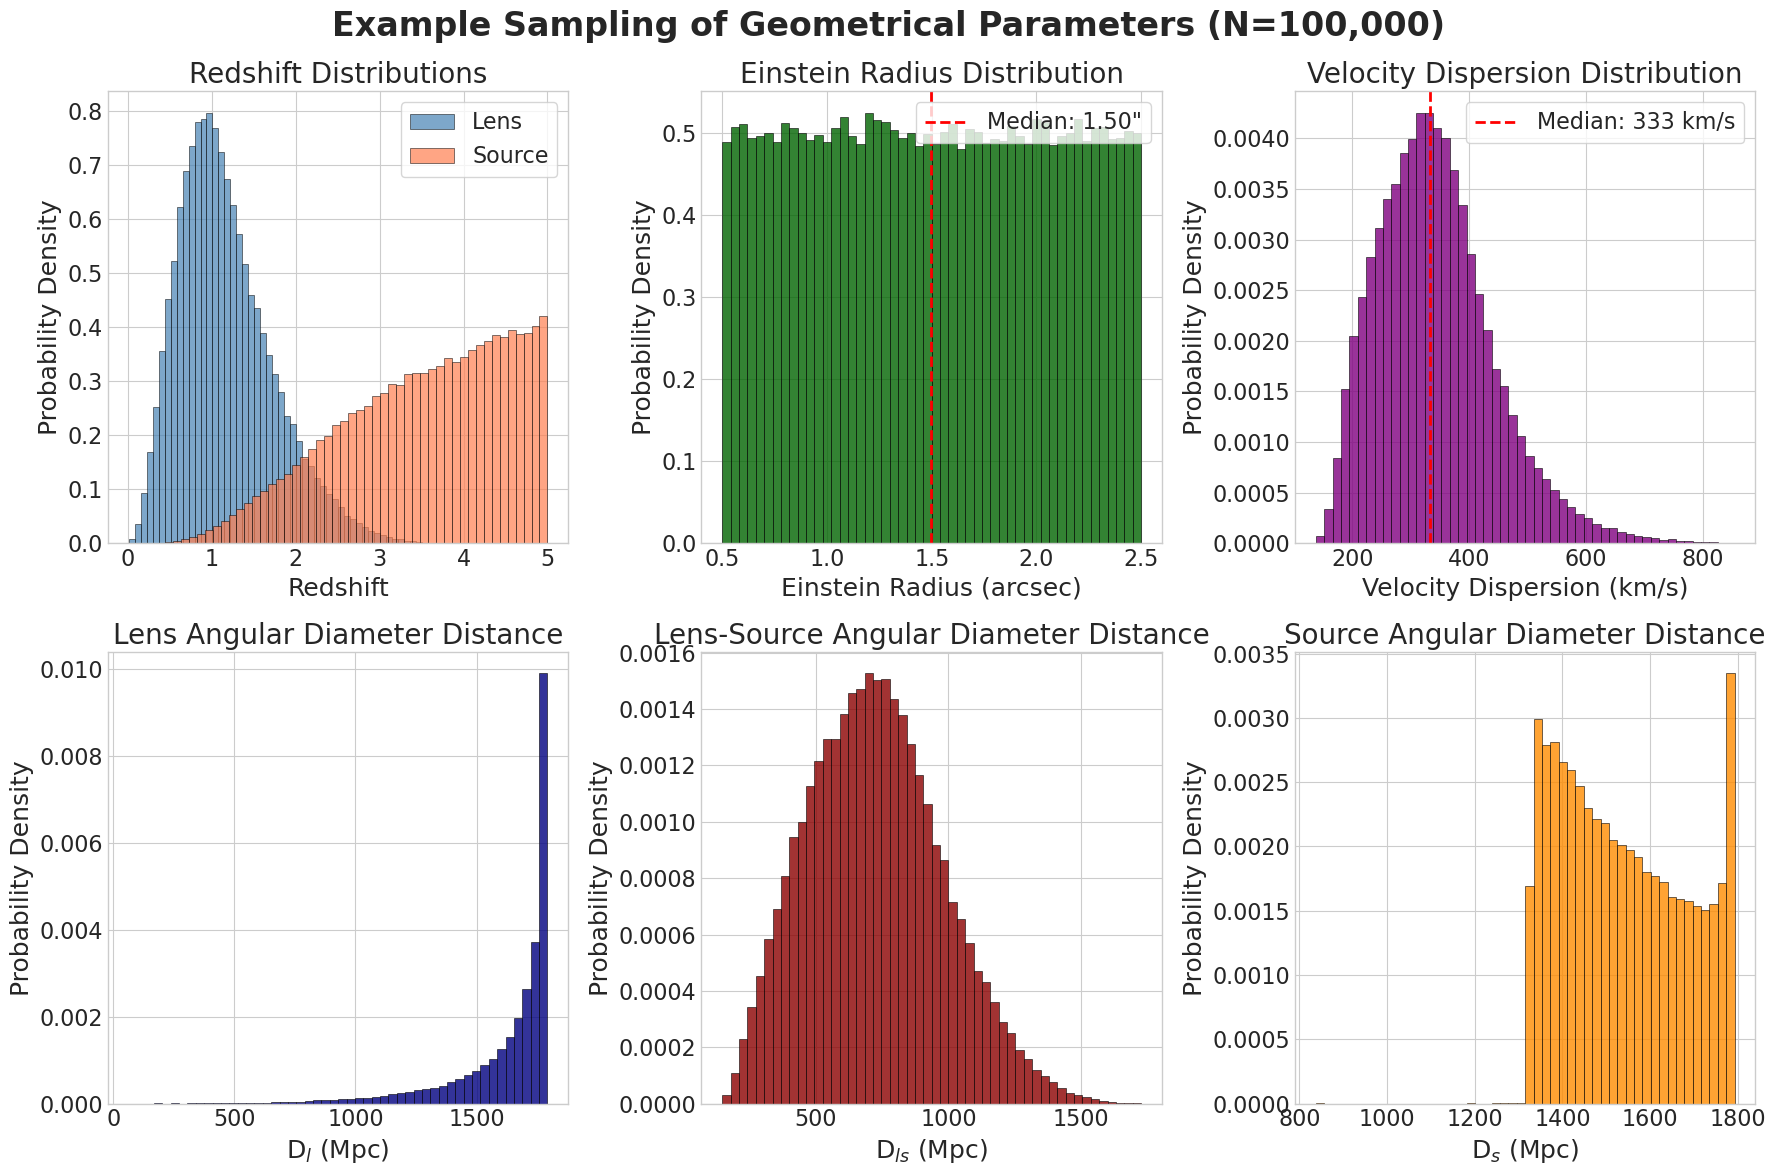


SUMMARY STATISTICS (N = 100,000)

Lens redshift:       1.166 ± 0.557
Source redshift:     3.521 ± 0.999
Einstein radius:     1.500 ± 0.577 arcsec
Velocity dispersion: 342.3 ± 99.4 km/s
D_l:                 1624 ± 222 Mpc
D_ls:                724 ± 255 Mpc
D_s:                 1537 ± 142 Mpc


In [6]:

module('load', 'pytorch/gpu-cuda-12.1/2.2.0')

from catalog_manager.make_system_dicts_new import Sampler, SamplingInputs,  RedshiftsVelDispModes, MainLensModes, SecondaryLensModes, SubStrucModes, SourceModes, SourcePosModes
import numpy as np
from config import CATALOGS_DIR
from shared_utils.physics_relations import r_max_moline


# Assuming all your sampling code is already loaded/imported
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Set default font sizes
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 20
})

# Set up sampling inputs exactly as in your test() functionquad
min_mass_log = 10.999
sampling_inputs = SamplingInputs(

        ThetaE_min   = 0.5,
        ThetaE_max   = 2.5,
        z_min=0.0,
        z_max=5.0,
        prior_lens_ThetaE=[0.5, 2.5],

        prior_lens_orient=[0, 2.* np.pi],
        prior_lens_pos=[-0.5, 0.5],
        prior_lens_q= [0.2, 1.0],
        prior_lens_slope_normal=[1.0, 0.1],
        prior_lens_VelDisp = [50, 400], 
    
        prior_sub_max_n = 0,
        prior_sub_pos= [- 3.0, + 3.0 ], # according to conor
        prior_sub_log_mass= [min_mass_log, 11.0], 
        prior_sub_r_max = [r_max_moline(10**min_mass_log) , r_max_moline(10**11.0) ],

        prior_source_I = 5e-14,         #if only one number, is fixed
        prior_source_std_main = 1.0, #kpc, a little bit low
        prior_source_frac_of_theta_pos= 0.3, #similar to conor
        prior_source_orient= 0., # not elliptical
        prior_source_q = 1. , # not elliptical

        prior_shear_d = [0., np.pi],
        prior_shear_s = [0., 0.1]
    )

# Pipeline as in your test()
My_Pipeline = [
    RedshiftsVelDispModes.RESAMPLE_THETA,
    MainLensModes.PEMD,
    SecondaryLensModes.EXTERNAL_SHEAR,
    SubStrucModes.NFW_subs_FIXED_R_MAX,
    SourceModes.GAUSS_SOURCE,
    SourcePosModes.RAND_FRAC_THETA_E
]

# Sample systems
full_sys_conf = Sampler(My_Pipeline, sampling_inputs, N_samples=100_000, cat_name="thesis_100k")

# Extract parameters
z_l = full_sys_conf.lens_par.z
z_s = full_sys_conf.source_par.z
sigma_v = full_sys_conf.lens_par.vel_disp
theta_E = full_sys_conf.precomp.theta_E * 206265.0  # Convert to arcsec
D_l = full_sys_conf.precomp.D_l
D_s = full_sys_conf.precomp.D_s
D_ls = full_sys_conf.precomp.D_ls

# Create figure with larger size for better visibility
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Example Sampling of Geometrical Parameters (N=100,000)', fontsize=24, fontweight='bold', y=0.98)

# 1. Redshifts
ax = axes[0,0]
ax.hist(z_l, bins=50, alpha=0.7, density=True, label='Lens', color='steelblue', edgecolor='black', linewidth=0.5)
ax.hist(z_s, bins=50, alpha=0.7, density=True, label='Source', color='coral', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Redshift', fontsize=18)
ax.set_ylabel('Probability Density', fontsize=18)
ax.set_title('Redshift Distributions', fontsize=20)
ax.legend(fontsize=16, frameon=True, fancybox=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# 2. Einstein radius
ax = axes[0,1]
ax.hist(theta_E, bins=50, density=True, color='darkgreen', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axvline(np.median(theta_E), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(theta_E):.2f}"')
ax.set_xlabel('Einstein Radius (arcsec)', fontsize=18)
ax.set_ylabel('Probability Density', fontsize=18)
ax.set_title('Einstein Radius Distribution', fontsize=20)
ax.legend(fontsize=16, frameon=True, fancybox=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# 3. Velocity dispersion
ax = axes[0,2]
ax.hist(sigma_v, bins=50, density=True, color='purple', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axvline(np.median(sigma_v), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(sigma_v):.0f} km/s')
ax.set_xlabel('Velocity Dispersion (km/s)', fontsize=18)
ax.set_ylabel('Probability Density', fontsize=18)
ax.set_title('Velocity Dispersion Distribution', fontsize=20)
ax.legend(fontsize=16, frameon=True, fancybox=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# 4. D_l distribution
ax = axes[1,0]
ax.hist(D_l, bins=50, density=True, color='navy', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_xlabel('D$_l$ (Mpc)', fontsize=18)
ax.set_ylabel('Probability Density', fontsize=18)
ax.set_title('Lens Angular Diameter Distance', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)

# 5. D_ls distribution
ax = axes[1,1]
ax.hist(D_ls, bins=50, density=True, color='darkred', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_xlabel('D$_{ls}$ (Mpc)', fontsize=18)
ax.set_ylabel('Probability Density', fontsize=18)
ax.set_title('Lens-Source Angular Diameter Distance', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)

# 6. D_s distribution
ax = axes[1,2]
ax.hist(D_s, bins=50, density=True, color='darkorange', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_xlabel('D$_s$ (Mpc)', fontsize=18)
ax.set_ylabel('Probability Density', fontsize=18)
ax.set_title('Source Angular Diameter Distance', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.savefig('thesis_lensing_parameters.pdf', dpi=300, bbox_inches='tight')
plt.savefig('thesis_lensing_parameters.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics with larger font
print("\n" + "="*60)
print(f"SUMMARY STATISTICS (N = {len(z_l):,})")
print("="*60)
print(f"\nLens redshift:       {np.mean(z_l):.3f} ± {np.std(z_l):.3f}")
print(f"Source redshift:     {np.mean(z_s):.3f} ± {np.std(z_s):.3f}")
print(f"Einstein radius:     {np.mean(theta_E):.3f} ± {np.std(theta_E):.3f} arcsec")
print(f"Velocity dispersion: {np.mean(sigma_v):.1f} ± {np.std(sigma_v):.1f} km/s")
print(f"D_l:                 {np.mean(D_l):.0f} ± {np.std(D_l):.0f} Mpc")
print(f"D_ls:                {np.mean(D_ls):.0f} ± {np.std(D_ls):.0f} Mpc")
print(f"D_s:                 {np.mean(D_s):.0f} ± {np.std(D_s):.0f} Mpc")
print("="*60)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Flat catalog written to /raven/u/fcitterio/master_thesis_code/catalogs/thesis_lens_params_100k.pth
Sampling configuration written to /raven/u/fcitterio/master_thesis_code/catalogs/sampling_configs/thesis_lens_params_100k.pth


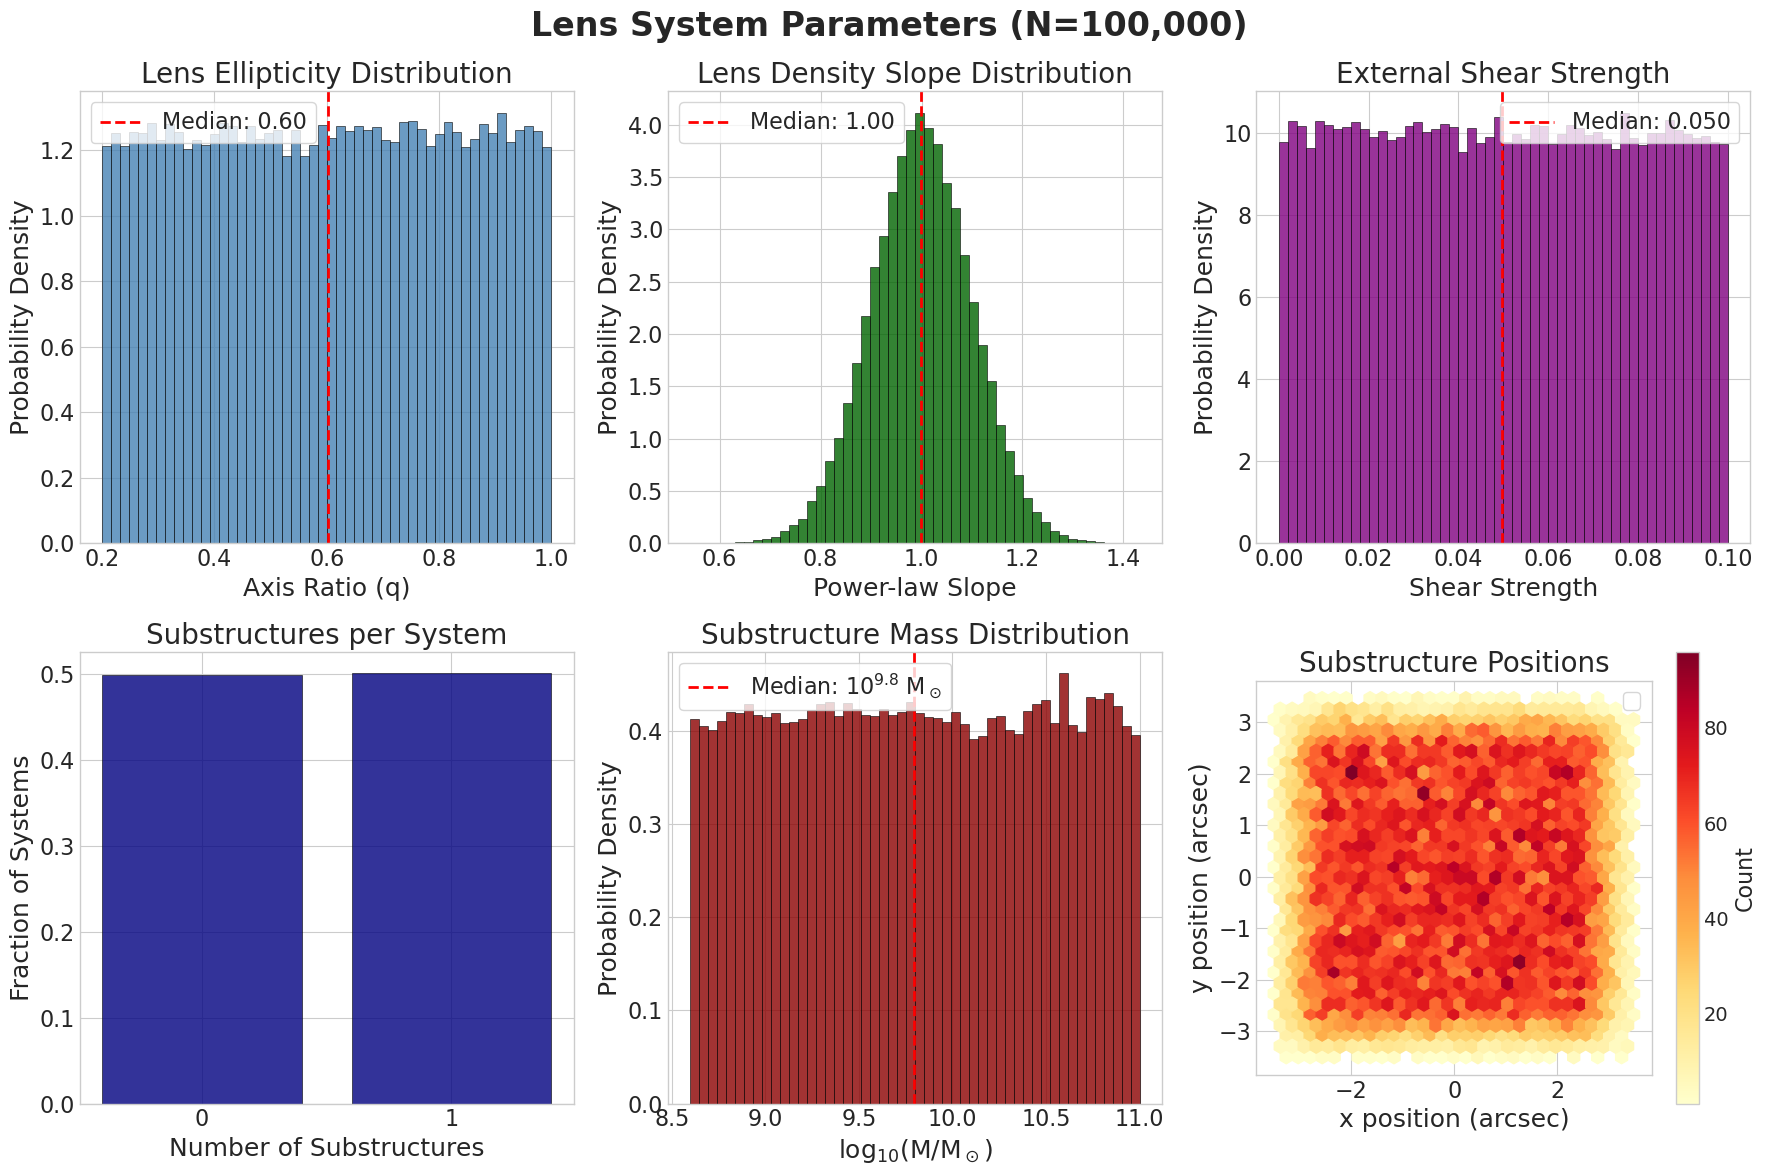


LENS PARAMETER STATISTICS (N = 100,000)

Lens axis ratio (q):    0.601 ± 0.231
Lens slope:             1.000 ± 0.100
Lens orientation:       180.1 ± 104.2 degrees
External shear:         0.0499 ± 0.0289
Shear angle:            90.1 ± 52.0 degrees

SUBSTRUCTURE STATISTICS
------------------------------------------------------------
Total substructures:    50,076
Systems with subs:      50,076 (50.1%)
Avg subs per system:    0.50 ± 0.50
Substructure masses:    10^9.80 ± 10^0.69 M☉
Typical distance:       2.39 arcsec from center


In [11]:
module('load', 'pytorch/gpu-cuda-12.1/2.2.0')

from catalog_manager.make_system_dicts_new import Sampler, SamplingInputs,  RedshiftsVelDispModes, MainLensModes, SecondaryLensModes, SubStrucModes, SourceModes, SourcePosModes
import numpy as np
from config import CATALOGS_DIR
from shared_utils.physics_relations import r_max_moline


# Assuming all your sampling code is already loaded/imported
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Set default font sizes
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 20
})

# Set up sampling inputs exactly as in your test() function
min_mass_log = 8.0  # Changed to allow substructures
min_mass_log = 10.999
sampling_inputs = SamplingInputs(

        ThetaE_min   = 0.5,
        ThetaE_max   = 2.5,
        z_min=0.0,
        z_max=5.0,
        prior_lens_ThetaE=[0.5, 2.5],

        prior_lens_orient=[0, 2.* np.pi],
        prior_lens_pos=[-0.5, 0.5],
        prior_lens_q= [0.2, 1.0],
        prior_lens_slope_normal=[1.0, 0.1],
        prior_lens_VelDisp = [50, 400], 
    
        prior_sub_max_n = 1,
        prior_sub_pos= [- 3.0, + 3.0 ], # according to conor
        prior_sub_log_mass= [8.6, 11.0], 
        prior_sub_r_max = [r_max_moline(10**8.6) , r_max_moline(10**11.0) ],

        prior_source_I = 5e-14,         #if only one number, is fixed
        prior_source_std_main = 1.0, #kpc, a little bit low
        prior_source_frac_of_theta_pos= 0.3, #similar to conor
        prior_source_orient= 0., # not elliptical
        prior_source_q = 1. , # not elliptical

        prior_shear_d = [0., np.pi],
        prior_shear_s = [0., 0.1]
    )
# Pipeline as in your test()
My_Pipeline = [
    RedshiftsVelDispModes.RESAMPLE_THETA,
    MainLensModes.PEMD,
    SecondaryLensModes.EXTERNAL_SHEAR,
    SubStrucModes.NFW_subs_FIXED_R_MAX,
    SourceModes.GAUSS_SOURCE,
    SourcePosModes.RAND_FRAC_THETA_E
]

# Sample systems
full_sys_conf = Sampler(My_Pipeline, sampling_inputs, N_samples=100_000, cat_name="thesis_lens_params_100k")

# Extract LENS parameters
lens_q = full_sys_conf.lens_par.q
lens_slope = full_sys_conf.lens_par.slope
lens_orient = full_sys_conf.lens_par.orient * 180.0 / np.pi  # Convert to degrees
lens_pos = full_sys_conf.lens_par.pos * 206265.0  # Convert to arcsec

# Extract EXTERNAL SHEAR parameters
shear_s = full_sys_conf.secondary_lens_par[0].s  # Shear strength
shear_d = full_sys_conf.secondary_lens_par[0].d * 180.0 / np.pi  # Shear angle in degrees

# Extract SUBSTRUCTURE parameters
sub_masses = full_sys_conf.sub_par.M_max
sub_r_max = full_sys_conf.sub_par.r_max
sub_pos = full_sys_conf.sub_par.pos_abs * 206265.0  # Convert to arcsec
n_subs_per_system = np.bincount(full_sys_conf.sub_par.belonging_index)

# Create figure with larger size for better visibility
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Lens System Parameters (N=100,000)', fontsize=24, fontweight='bold', y=0.98)

# 1. Lens ellipticity (q)
ax = axes[0,0]
ax.hist(lens_q, bins=50, density=True, color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axvline(np.median(lens_q), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(lens_q):.2f}')
ax.set_xlabel('Axis Ratio (q)', fontsize=18)
ax.set_ylabel('Probability Density', fontsize=18)
ax.set_title('Lens Ellipticity Distribution', fontsize=20)
ax.legend(fontsize=16, frameon=True, fancybox=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# 2. Lens slope
ax = axes[0,1]
ax.hist(lens_slope, bins=50, density=True, color='darkgreen', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axvline(np.median(lens_slope), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(lens_slope):.2f}')
ax.set_xlabel('Power-law Slope', fontsize=18)
ax.set_ylabel('Probability Density', fontsize=18)
ax.set_title('Lens Density Slope Distribution', fontsize=20)
ax.legend(fontsize=16, frameon=True, fancybox=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# 3. External shear strength
ax = axes[0,2]
ax.hist(shear_s, bins=50, density=True, color='purple', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axvline(np.median(shear_s), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(shear_s):.3f}')
ax.set_xlabel('Shear Strength', fontsize=18)
ax.set_ylabel('Probability Density', fontsize=18)
ax.set_title('External Shear Strength', fontsize=20)
ax.legend(fontsize=16, frameon=True, fancybox=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# 4. Number of substructures per system
ax = axes[1,0]
unique_counts, count_freq = np.unique(n_subs_per_system, return_counts=True)
ax.bar(unique_counts, count_freq/len(n_subs_per_system), color='navy', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Substructures', fontsize=18)
ax.set_ylabel('Fraction of Systems', fontsize=18)
ax.set_title('Substructures per System', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xticks(unique_counts)

# 5. Substructure mass distribution
ax = axes[1,1]
if len(sub_masses) > 0:
    ax.hist(np.log10(sub_masses), bins=50, density=True, color='darkred', alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.axvline(np.median(np.log10(sub_masses)), color='red', linestyle='--', linewidth=2, 
               label=f'Median: 10$^{{{np.median(np.log10(sub_masses)):.1f}}}$ M$_\odot$')
    ax.set_xlabel('log$_{10}$(M/M$_\odot$)', fontsize=18)
    ax.set_ylabel('Probability Density', fontsize=18)
    ax.set_title('Substructure Mass Distribution', fontsize=20)
    ax.legend(fontsize=16, frameon=True, fancybox=True)
else:
    ax.text(0.5, 0.5, 'No substructures', transform=ax.transAxes, 
            ha='center', va='center', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)

# 6. Substructure positions
ax = axes[1,2]
if len(sub_pos) > 0:
    # Show 2D distribution of substructure positions
    hexbin = ax.hexbin(sub_pos[:, 0], sub_pos[:, 1], gridsize=30, cmap='YlOrRd', mincnt=1)
    ax.set_xlabel('x position (arcsec)', fontsize=18)
    ax.set_ylabel('y position (arcsec)', fontsize=18)
    ax.set_title('Substructure Positions', fontsize=20)
    ax.set_aspect('equal')
    # Add circle showing typical Einstein radius
    
    ax.legend(fontsize=16, frameon=True, fancybox=True)
    cbar = plt.colorbar(hexbin, ax=ax)
    cbar.set_label('Count', fontsize=16)
    cbar.ax.tick_params(labelsize=14)
else:
    ax.text(0.5, 0.5, 'No substructures', transform=ax.transAxes, 
            ha='center', va='center', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.savefig('thesis_lens_parameters.pdf', dpi=300, bbox_inches='tight')
plt.savefig('thesis_lens_parameters.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics with larger font
print("\n" + "="*60)
print(f"LENS PARAMETER STATISTICS (N = {len(lens_q):,})")
print("="*60)
print(f"\nLens axis ratio (q):    {np.mean(lens_q):.3f} ± {np.std(lens_q):.3f}")
print(f"Lens slope:             {np.mean(lens_slope):.3f} ± {np.std(lens_slope):.3f}")
print(f"Lens orientation:       {np.mean(lens_orient):.1f} ± {np.std(lens_orient):.1f} degrees")
print(f"External shear:         {np.mean(shear_s):.4f} ± {np.std(shear_s):.4f}")
print(f"Shear angle:            {np.mean(shear_d):.1f} ± {np.std(shear_d):.1f} degrees")
print(f"\nSUBSTRUCTURE STATISTICS")
print("-"*60)
print(f"Total substructures:    {len(sub_masses):,}")
print(f"Systems with subs:      {np.sum(n_subs_per_system > 0):,} ({100*np.sum(n_subs_per_system > 0)/len(n_subs_per_system):.1f}%)")
print(f"Avg subs per system:    {np.mean(n_subs_per_system):.2f} ± {np.std(n_subs_per_system):.2f}")
if len(sub_masses) > 0:
    print(f"Substructure masses:    10^{np.mean(np.log10(sub_masses)):.2f} ± 10^{np.std(np.log10(sub_masses)):.2f} M☉")
    print(f"Typical distance:       {np.median(np.sqrt(sub_pos[:,0]**2 + sub_pos[:,1]**2)):.2f} arcsec from center")
print("="*60)

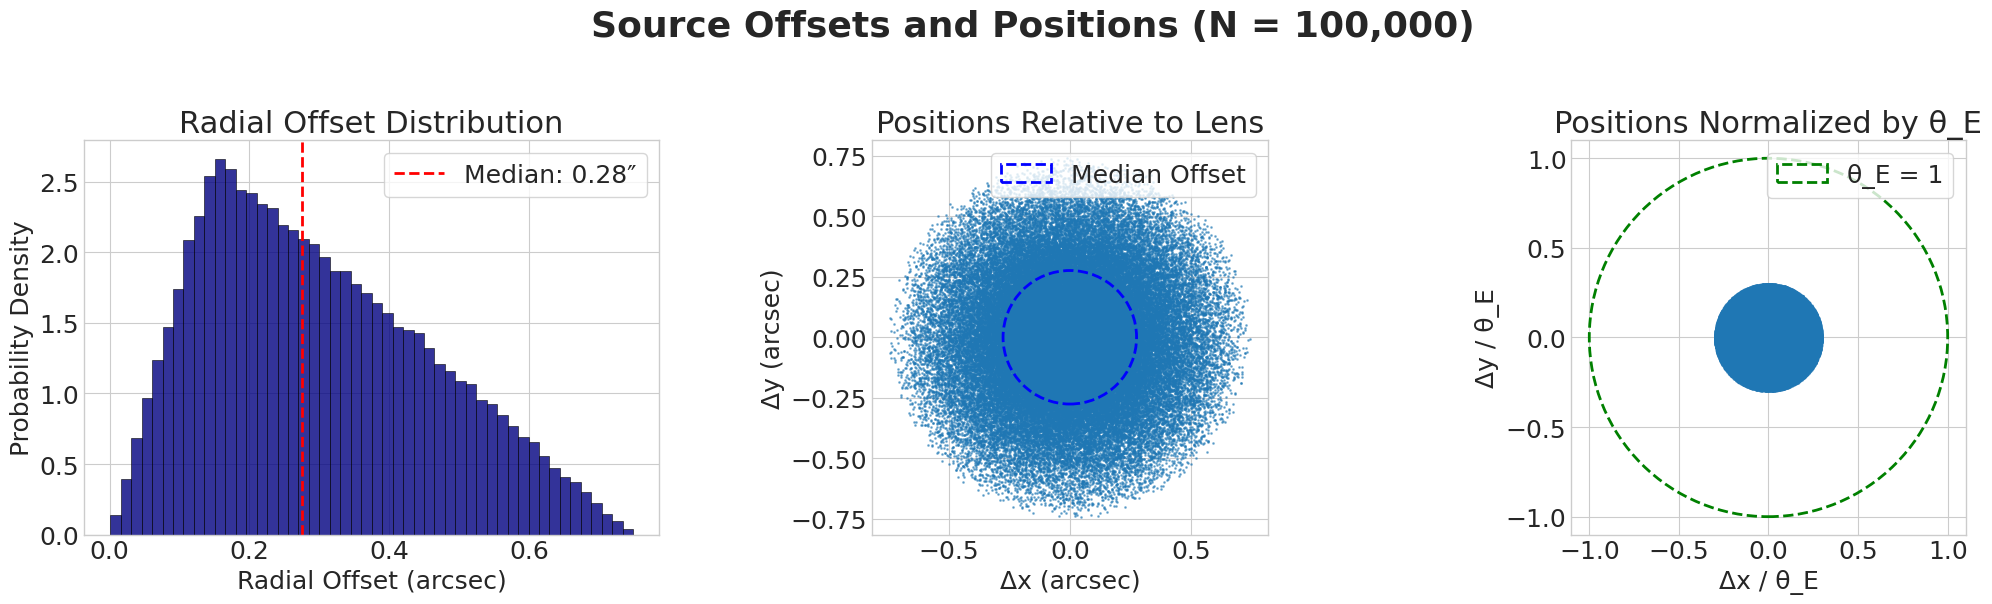

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Increase text sizes
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 20,
    'axes.titlesize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'figure.titlesize': 24
})
plt.style.use('seaborn-v0_8-whitegrid')

# --- Run this right after your Sampler(...) so full_sys_conf exists ---

# Convert positions and Einstein angles to arcsec
pos_src  = full_sys_conf.source_par.pos_abs * 206265.0
lens_pos = full_sys_conf.lens_par.pos    * 206265.0
theta_E  = full_sys_conf.precomp.theta_E * 206265.0

# Compute relative offsets and normalized positions
pos_rel  = pos_src - lens_pos
radii    = np.sqrt((pos_rel**2).sum(axis=1))
pos_norm = pos_rel / theta_E[:, None]

# Create 1×3 row of subplots
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Source Offsets and Positions (N = {:,})'.format(len(radii)),
             fontsize=26, fontweight='bold', y=1.02)

# 1. Radial offset distribution
ax = axes[0]
ax.hist(radii, bins=50, density=True, color='navy', alpha=0.8,
        edgecolor='black', linewidth=0.5)
ax.axvline(np.median(radii), color='red', linestyle='--', linewidth=2,
           label=f'Median: {np.median(radii):.2f}″')
ax.set_xlabel('Radial Offset (arcsec)')
ax.set_ylabel('Probability Density')
ax.set_title('Radial Offset Distribution')
ax.legend(frameon=True, fancybox=True)
ax.tick_params(labelsize=18)

# 2. Positions relative to lens
ax = axes[1]
ax.scatter(pos_rel[:, 0], pos_rel[:, 1], s=1, alpha=0.5)
circle = Circle((0, 0), np.median(radii), fill=False, color='blue',
                linestyle='--', linewidth=2, label='Median Offset')
ax.add_patch(circle)
ax.set_xlabel('Δx (arcsec)')
ax.set_ylabel('Δy (arcsec)')
ax.set_title('Positions Relative to Lens')
ax.set_aspect('equal')
ax.legend(frameon=True, fancybox=True)
ax.tick_params(labelsize=18)

# 3. Normalized positions by Einstein radius
ax = axes[2]
ax.scatter(pos_norm[:, 0], pos_norm[:, 1], s=1, alpha=0.2)
unit_circle = Circle((0, 0), 1, fill=False, color='green',
                     linestyle='--', linewidth=2, label='θ_E = 1')
ax.add_patch(unit_circle)
ax.set_xlabel('Δx / θ_E')
ax.set_ylabel('Δy / θ_E')
ax.set_title('Positions Normalized by θ_E')
ax.set_aspect('equal')
ax.legend(frameon=True, fancybox=True)
ax.tick_params(labelsize=18)

plt.tight_layout()
plt.savefig('thesis_source_offsets_combined_larger_text.pdf', dpi=300, bbox_inches='tight')
plt.savefig('thesis_source_offsets_combined_larger_text.png', dpi=300, bbox_inches='tight')
plt.show()




In [9]:
from torchviz import make_dot
import torch
from deep_learning import ResNet50
model = ResNet50(num_classes=2)
x = torch.randn(1, 1, 80, 80)
y = model(x)
dot = make_dot(y, params=dict(model.named_parameters()))
dot.format = "png"
dot.render("resnet50_80x80_torchviz")  # saves resnet50_80x80_torchviz.png


ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [8]:
!module avail graphviz
!module load graphviz
!which dot && dot -V


----------------------- /mpcdf/soft/SLE_15/modules/tools -----------------------
graphviz/2.44  graphviz/8  

Key:
modulepath  default-version  

----------------------------- MPCDF specific note ------------------------------
>Not all modules are visible immediately, for most you first need to load their
prerequisites, see https://docs.mpcdf.mpg.de for more details. Typically those
are your compiler and/or MPI module of choice, as well your desired Python
stack, CUDA version, etc.

You can search in the full hierarchy of installed modules with

  find-module

(You can disable this hint by "export MPCDF_DISABLE_MODULE_AVAIL_HINT=1", e.g. in your .bashrc)

which: no dot in (/mpcdf/soft/SLE_15/packages/x86_64/anaconda/3/2023.03/bin:/mpcdf/soft/SLE_15/packages/x86_64/anaconda/3/2023.03/bin:/mpcdf/soft/SLE_15/packages/x86_64/rvs-cloud/1.0/bin:/opt/VirtualGL/bin:/opt/TurboVNC/bin:/mpcdf/soft/SLE_15/packages/x86_64/anaconda/3/2021.05/condabin:/mpcdf/soft/SLE_15/packages/x86_64/Modules/5.4.0